<div style="background:linear-gradient(135deg,#1e3a8a 0%,#0c1a3d 100%);border-radius:16px;padding:30px 34px;color:#eff6ff;margin-bottom:6px;">
<div style="font-size:12.5px;letter-spacing:3px;text-transform:uppercase;opacity:.65;font-weight:600;">News Article Topic Classification</div>
<div style="font-size:30px;font-weight:800;margin:6px 0 10px;">05 · Visualization</div>
<div style="font-size:14.5px;opacity:.92;max-width:640px;line-height:1.55;">Class balance, source/page_rank distributions, confusion matrix, and per-model comparison.</div>
</div>

<div style="margin:12px 0 6px;">
<span style="display:inline-block;background:#e2e8f0;color:#64748b;padding:4px 12px;border-radius:20px;font-size:11.5px;margin-right:5px;">01 Load Data</span><span style="display:inline-block;background:#e2e8f0;color:#64748b;padding:4px 12px;border-radius:20px;font-size:11.5px;margin-right:5px;">02 Preprocessing</span><span style="display:inline-block;background:#e2e8f0;color:#64748b;padding:4px 12px;border-radius:20px;font-size:11.5px;margin-right:5px;">03 Modeling</span><span style="display:inline-block;background:#e2e8f0;color:#64748b;padding:4px 12px;border-radius:20px;font-size:11.5px;margin-right:5px;">04 Evaluation & Testing</span><span style="display:inline-block;background:#1e3a8a;color:#fff;padding:4px 12px;border-radius:20px;font-size:11.5px;margin-right:5px;font-weight:600;">05 Visualization</span>
</div>

<div style="margin:8px 0 14px;">
<span style="display:inline-block;background:#eff6ff;border:1px solid #93c5fd;border-radius:8px;padding:7px 14px;font-size:13px;margin-right:8px;">
<b style="color:#1e3a8a;">⬅ Requires</b>&nbsp; <code>artifacts/02_preprocessing.pkl</code> &amp; <code>artifacts/03_modeling.pkl</code> — run those two notebooks once beforehand
</span><span style="display:inline-block;background:#eff6ff;border:1px solid #93c5fd;border-radius:8px;padding:7px 14px;font-size:13px;margin-right:8px;">
<b style="color:#1e3a8a;">➡ Produces</b>&nbsp; the charts below
</span><span style="display:inline-block;background:#eff6ff;border:1px solid #93c5fd;border-radius:8px;padding:7px 14px;font-size:13px;margin-right:8px;">
<b style="color:#1e3a8a;">ℹ Note</b>&nbsp; nothing here is recomputed — every figure reuses values those two notebooks already produced
</span>
</div>

## <span style="color:#fff;">Load Artifacts</span>
<div style="height:3px;width:48px;background:#2563eb;border-radius:2px;margin:2px 0 10px;"></div>



In [1]:
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support

from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Projects/DSL/News Classification/'
ARTIFACT_DIR = BASE_PATH + 'artifacts/'

with open(ARTIFACT_DIR + '02_preprocessing.pkl', 'rb') as f:
    _art02 = pickle.load(f)
with open(ARTIFACT_DIR + '03_modeling.pkl', 'rb') as f:
    _art03 = pickle.load(f)

X_Train              = _art02['X_Train']
label_dist           = _art02['label_dist']
Y_Validation_aligned = _art02['Y_Validation_aligned']
final_pred           = _art03['final_pred']
leaderboard          = _art03['leaderboard']
cm                   = _art03['cm']

LABEL_NAMES = {0: 'International', 1: 'Business', 2: 'Technology',
               3: 'Entertainment', 4: 'Sports', 5: 'General', 6: 'Health'}

sns.set_style("whitegrid")
print(f"✓ Loaded artifacts from {ARTIFACT_DIR}02_preprocessing.pkl and 03_modeling.pkl")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Loaded artifacts from /content/drive/MyDrive/Projects/DSL/News Classification/artifacts/02_preprocessing.pkl and 03_modeling.pkl


## <span style="color:#fff;">Label Distribution</span>
<div style="height:3px;width:48px;background:#2563eb;border-radius:2px;margin:2px 0 10px;"></div>

Class balance across the 7 topic categories in the training data.

<span style="display:inline-block;background:#eff6ff;color:#1e3a8a;padding:2px 10px;border-radius:12px;font-size:11.5px;margin-top:4px;">Chart 1</span>

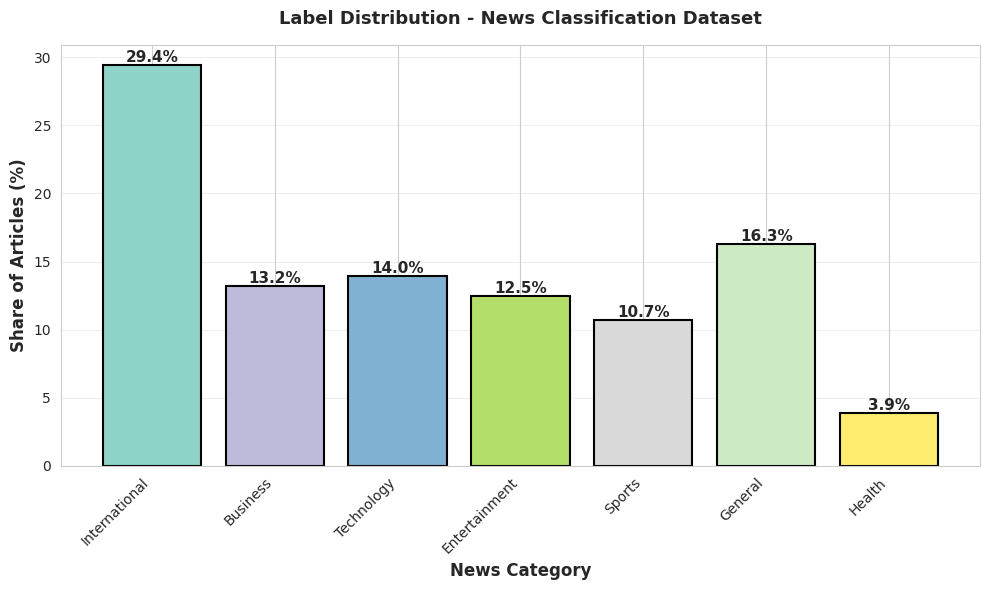

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
label_names_list = [LABEL_NAMES[i] for i in range(7)]
counts = (label_dist * 100).reindex(range(7))
colors = plt.cm.Set3(np.linspace(0, 1, 7))
bars = ax.bar(label_names_list, counts.values, color=colors, edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xlabel('News Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Share of Articles (%)', fontsize=12, fontweight='bold')
ax.set_title('Label Distribution - News Classification Dataset', fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## <span style="color:#fff;">Confusion Matrix</span>
<div style="height:3px;width:48px;background:#2563eb;border-radius:2px;margin:2px 0 10px;"></div>

Predicted vs. true label on the validation set, for the final Voting ensemble.

<span style="display:inline-block;background:#eff6ff;color:#1e3a8a;padding:2px 10px;border-radius:12px;font-size:11.5px;margin-top:4px;">Chart 2</span>

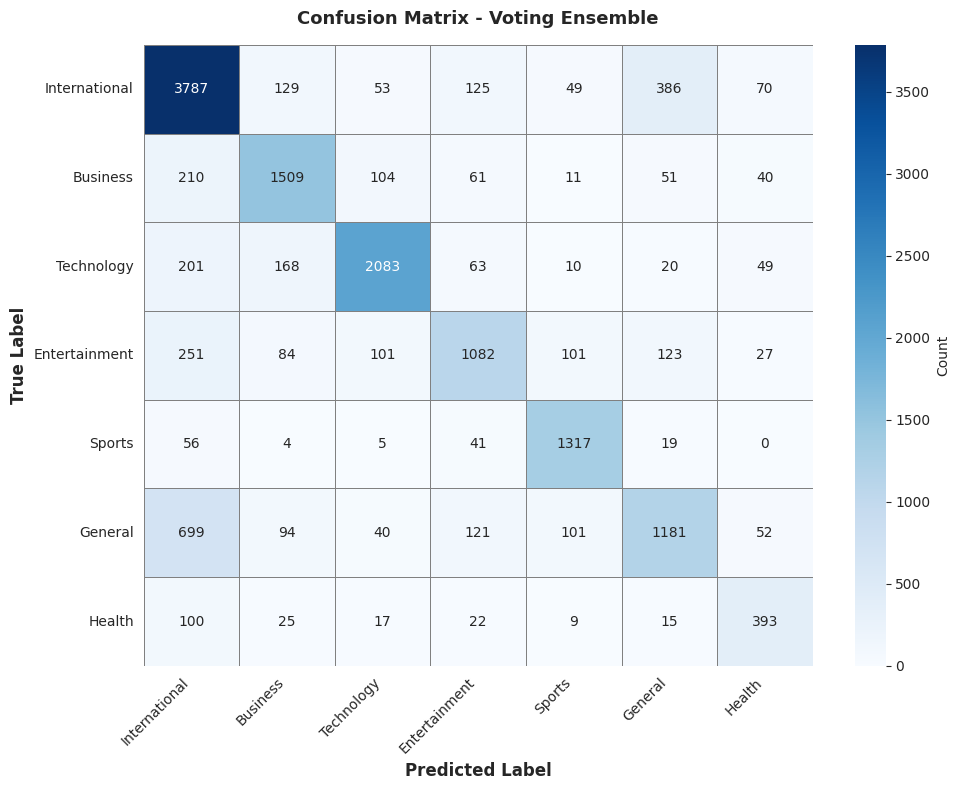

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))
label_names_list = [LABEL_NAMES[i] for i in range(7)]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=label_names_list, yticklabels=label_names_list,
            cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Voting Ensemble', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## <span style="color:#fff;">Per-Class Performance</span>
<div style="height:3px;width:48px;background:#2563eb;border-radius:2px;margin:2px 0 10px;"></div>

Precision, recall, and F1 for each of the 7 categories.

<span style="display:inline-block;background:#eff6ff;color:#1e3a8a;padding:2px 10px;border-radius:12px;font-size:11.5px;margin-top:4px;">Chart 3</span>

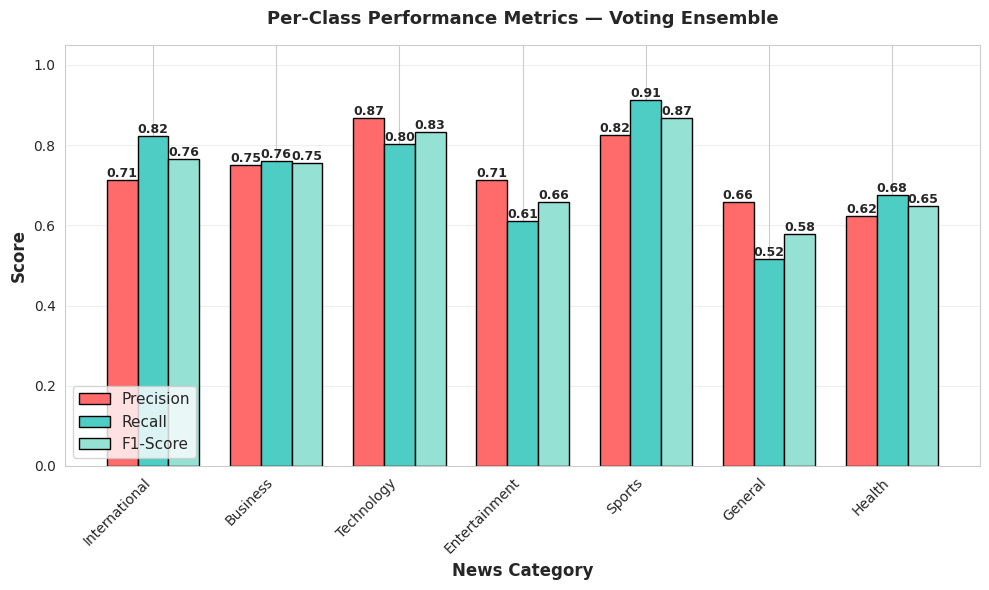

In [4]:
precision, recall, f1_scores, _ = precision_recall_fscore_support(Y_Validation_aligned, final_pred, average=None)

fig, ax = plt.subplots(figsize=(10, 6))
label_names_list = [LABEL_NAMES[i] for i in range(7)]
x_pos = np.arange(len(label_names_list))
width = 0.25

bars1 = ax.bar(x_pos - width, precision, width, label='Precision', color='#FF6B6B', edgecolor='black', linewidth=1)
bars2 = ax.bar(x_pos, recall, width, label='Recall', color='#4ECDC4', edgecolor='black', linewidth=1)
bars3 = ax.bar(x_pos + width, f1_scores, width, label='F1-Score', color='#95E1D3', edgecolor='black', linewidth=1)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('News Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics — Voting Ensemble', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(label_names_list, rotation=45, ha='right')
ax.legend(fontsize=11, loc='lower left')
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## <span style="color:#fff;">Model Comparison</span>
<div style="height:3px;width:48px;background:#2563eb;border-radius:2px;margin:2px 0 10px;"></div>

Every candidate from the allowed model zoo, ranked by validation Macro F1.

<span style="display:inline-block;background:#eff6ff;color:#1e3a8a;padding:2px 10px;border-radius:12px;font-size:11.5px;margin-top:4px;">Chart 4</span>

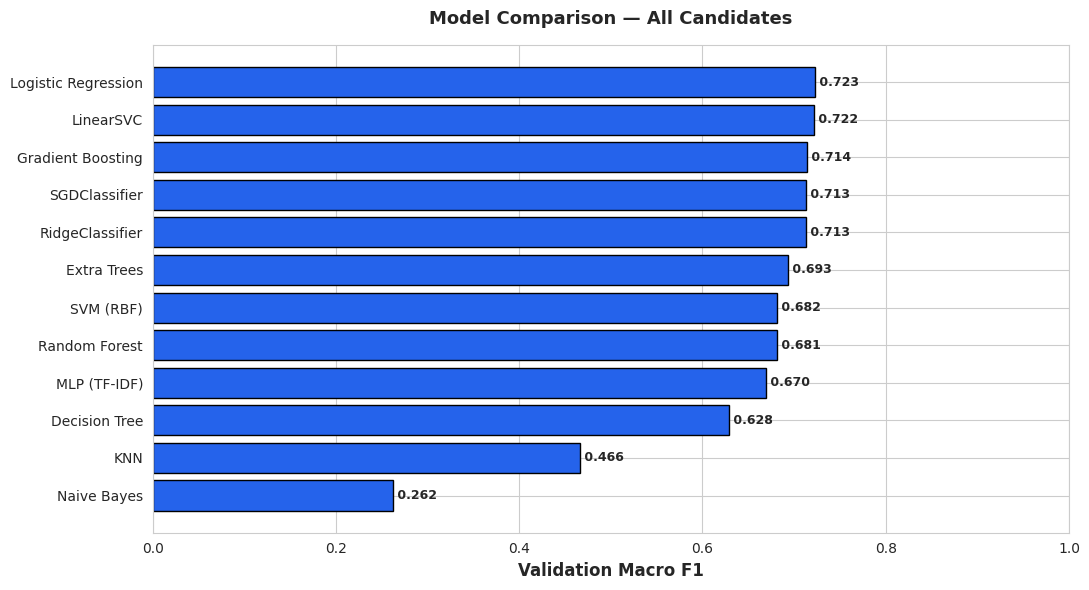

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = leaderboard.sort_values('val_macro_f1', ascending=True)
colors = ['#2563eb' if m != 'Voting Ensemble' else '#f59e0b' for m in plot_df['model']]
ax.barh(plot_df['model'], plot_df['val_macro_f1'], color='#2563eb', edgecolor='black', linewidth=1)
for i, v in enumerate(plot_df['val_macro_f1']):
    ax.text(v, i, f' {v:.3f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Validation Macro F1', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison — All Candidates', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, 1.0)
plt.tight_layout()
plt.show()